In [1]:
import numpy as np 
import pandas as pd
import seaborn as sns
import warnings
import datetime as dt
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans



In [2]:

df = pd.read_csv("Datasets/OnlineRetail.csv",encoding="unicode_escape")
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [3]:
df.shape

(541909, 8)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [5]:
df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [6]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [7]:
df.dropna()

df['CustomerID'].dtype


dtype('float64')

In [8]:
df["CustomerID"] = df["CustomerID"].astype(str)

In [9]:
df["Amount"] = df['Quantity']*df['UnitPrice']
df_m = df.groupby('CustomerID')['Amount'].sum()
df_m = df_m.reset_index()
df_m.head()

,CustomerID,Amount
0,12346.0,0.00
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40


In [10]:
df_f = df.groupby('CustomerID')['InvoiceNo'].count()
df_f = df_f.reset_index()
df_f.columns = ['CustomerID','Frequency']
df_f.head()

,CustomerID,Frequency
0,12346.0,2
1,12347.0,182
2,12348.0,31
3,12349.0,73
4,12350.0,17


In [11]:
df_retail = pd.merge(df_m,df_f, on='CustomerID',how='inner')
df_retail.head()


,CustomerID,Amount,Frequency
0,12346.0,0.00,2
1,12347.0,4310.00,182
2,12348.0,1797.24,31
3,12349.0,1757.55,73
4,12350.0,334.40,17


In [12]:
# This is useul for performing various date-related operations and analyses on the data
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'],format = '%d-%m-%Y %H:%M')
df

ValueError: time data "12/1/2010 8:26" doesn't match format "%d-%m-%Y %H:%M". You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [ ]:
# Compute the maximum date to know the last transaction date 
# This tells you the last transaction date in the dataset.
max_date = max(df['InvoiceDate'])
max_date

Timestamp('2011-12-09 12:50:00')

In [ ]:
# Compute the difference between max date and transaction date
df['Diff'] = max_date - df['InvoiceDate']
df.head(100)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Amount,Diff
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,373 days 04:24:00
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,373 days 04:24:00
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,373 days 04:24:00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,373 days 04:24:00
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,373 days 04:24:00
...,...,...,...,...,...,...,...,...,...,...
95,536378,22352,LUNCH BOX WITH CUTLERY RETROSPOT,6,2010-12-01 09:37:00,2.55,14688.0,United Kingdom,15.30,373 days 03:13:00
96,536378,21212,PACK OF 72 RETROSPOT CAKE CASES,120,2010-12-01 09:37:00,0.42,14688.0,United Kingdom,50.40,373 days 03:13:00
97,536378,21975,PACK OF 60 DINOSAUR CAKE CASES,24,2010-12-01 09:37:00,0.55,14688.0,United Kingdom,13.20,373 days 03:13:00
98,536378,21977,PACK OF 60 PINK PAISLEY CAKE CASES,24,2010-12-01 09:37:00,0.55,14688.0,United Kingdom,13.20,373 days 03:13:00


In [ ]:
# Compute last transaction date to get the recency o customers
df_p = df.groupby('CustomerID')['Diff'].min()
df_p = df_p.reset_index()
df_p.head()

,CustomerID,Diff
0,12346.0,325 days 02:33:00
1,12347.0,1 days 20:58:00
2,12348.0,74 days 23:37:00
3,12349.0,18 days 02:59:00
4,12350.0,309 days 20:49:00


In [ ]:
# Extract number of days only

df_p['Diff'] = df_p['Diff']
df_p.head()


,CustomerID,Diff
0,12346.0,325
1,12347.0,1
2,12348.0,74
3,12349.0,18
4,12350.0,309


In [ ]:
df_p['Diff'].dtype
df_retail.columns = ['CustomerID','Amount','Frequency','Recency']

dtype('int64')

In [ ]:
# Merge the dataframes to get the fnal RFM dataframe

df_retail = pd.merge(df_retail,df_p,on='CustomerID',how ='inner')

df_retail.columns = ['CustomerID','Amount','Frequency','Recency']
df_retail.head()
                     

,CustomerID,Amount,Frequency,Recency
0,12346.0,0.00,2,325
1,12347.0,4310.00,182,1
2,12348.0,1797.24,31,74
3,12349.0,1757.55,73,18
4,12350.0,334.40,17,309


In [ ]:
df_retail.shape

(4372, 4)

Text(0.5, 0, 'Attributes')

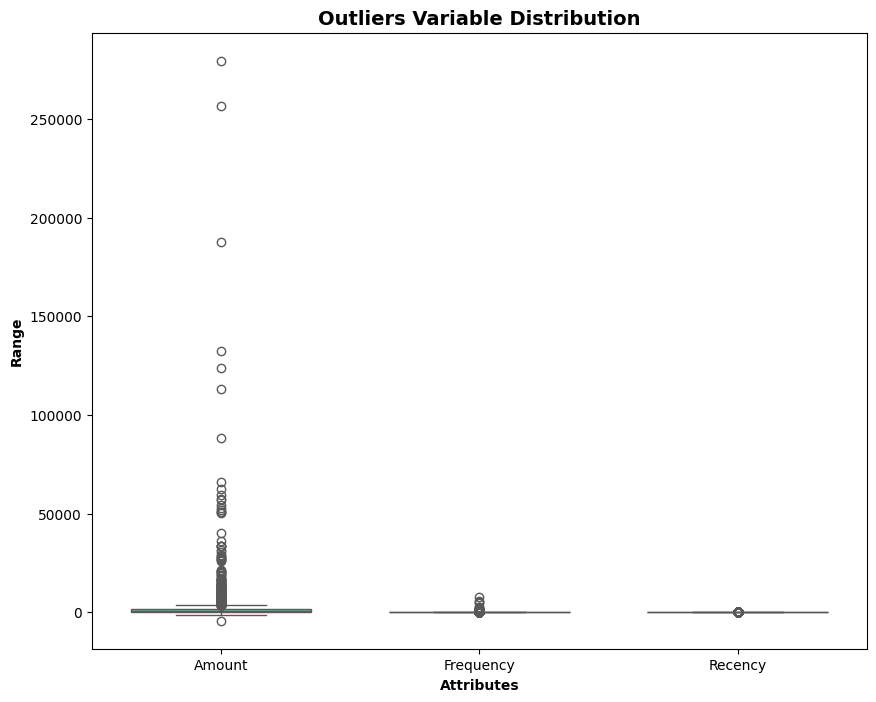

In [ ]:
attributes = ['Amount','Frequency','Recency']
plt.rcParams['figure.figsize']=[10,8]
sns.boxplot(data=df_retail[attributes],orient='v',palette='Set2',whis=1.5,saturation=1,width= 0.7)
plt.title("Outliers Variable Distribution",fontsize='14',fontweight='bold')
plt.ylabel('Range',fontweight='bold')
plt.xlabel('Attributes',fontweight='bold')

In [ ]:
Q1 = df_retail.Amount.quantile(0.05)#Calculate the 5th percentile (Q1) of the 'Amount' attribute
Q3 = df_retail.Amount.quantile(0.95) #Calculate the 95th percentile (Q3)
IQR = Q3-Q1
df_retail = df_retail[(df_retail.Amount >= Q1 -1.5*IQR) & (df_retail.Amount <= Q3 + 1.5*IQR)]

# Removing (statistical) outliers for Recency

Q1 = df_retail.Recency.quantile(0.05)#Calculate the 5th percentile (Q1) of the 'Recency' attribute
Q3 = df_retail.Recency.quantile(0.95) #Calculate the 95th percentile (Q3)
IQR = Q3-Q1
df_retail = df_retail[(df_retail.Recency >= Q1 -1.5*IQR) & (df_retail.Recency <= Q3 + 1.5*IQR)]

# Removing (statistical) outliers for Frequency

Q1 = df_retail.Frequency.quantile(0.05)#Calculate the 5th percentile (Q1) of the 'Frequency' attribute
Q3 = df_retail.Frequency.quantile(0.95) #Calculate the 95th percentile (Q3)
IQR = Q3-Q1
df_retail = df_retail[(df_retail.Frequency >= Q1 -1.5*IQR) & (df_retail.Frequency <= Q3 + 1.5*IQR)]


In [ ]:
# Rescaling the attributes
# Feature scaling is important for various machine learning algorithms
# that are sensitive to scale of input features,ensuring that each feature
# contributes equally to the analysis or model training

df1 = df_retail[['Amount','Frequency','Recency']]

# Instantiate
scaler = StandardScaler()

# fit_transform
scaled_array = scaler.fit_transform(df1)
# df_retail_scaled.shape

df_retail_scaled= pd.DataFrame(
    scaled_array,
    columns= df1.columns,
    index = df1.index
)


In [ ]:
df_retail_scaled.head()

,Amount,Frequency,Recency
0,-0.723738,-0.752888,2.301611
1,1.731617,1.042467,-0.906466
2,0.300128,-0.463636,-0.183658
3,0.277517,-0.044720,-0.738141
4,-0.533235,-0.603275,2.143188


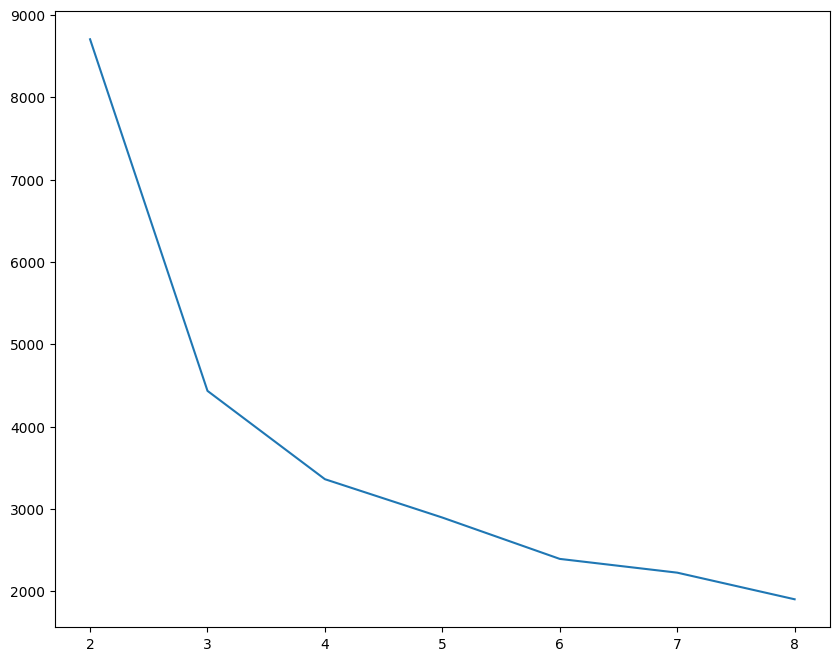

In [ ]:
ssd = [] # create an empty list ssd to store the same sum  of squared distances for different values
range_n_clusters = [2,3,4,5,6,7,8]# Define a range of potential values for the number of clusters
for num_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=num_clusters,max_iter=50)
    kmeans.fit(df_retail_scaled)

    ssd.append(kmeans.inertia_)

# Inertia provides insight into how tghtly the data points in a cluster are clustered around their centroid
# A lower inertia value indicates that the data points are closer to the centroids of the respective cluster

# plot the SSDs for each n_clusters
plt.plot(range_n_clusters,ssd)

In [ ]:
# Final model with k= 3
kmeans = KMeans(n_clusters=3,max_iter=50)
kmeans.fit(df_retail_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",50
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [ ]:
kmeans.labels_

array([1, 2, 0, ..., 1, 0, 0], shape=(4293,), dtype=int32)

In [ ]:
array([0,2,1, ...,0,1,1])

NameError: name 'array' is not defined

In [ ]:
# assgn the label
df_retail['Cluster_Id'] = kmeans.labels_
df_retail.head()

,CustomerID,Amount,Frequency,Recency,Cluster_Id
0,12346.0,0.00,2,325,1
1,12347.0,4310.00,182,1,2
2,12348.0,1797.24,31,74,0
3,12349.0,1757.55,73,18,0
4,12350.0,334.40,17,309,1


In [ ]:
df_retail['Cluster_Id'].value_counts(ascending=False)

Cluster_Id
0    2733
1    1068
2     492
Name: count, dtype: int64

In [ ]:
X = df_retail.iloc[:,[1,3]].values
X

array([[0.00000e+00, 3.25000e+02],
       [4.31000e+03, 1.00000e+00],
       [1.79724e+03, 7.40000e+01],
       ...,
       [8.08200e+01, 1.80000e+02],
       [1.76600e+02, 7.00000e+00],
       [1.83728e+03, 4.20000e+01]], shape=(4293, 2))

In [ ]:
y_kmeans = kmeans.fit_predict(X)
[y_kmeans==0]

[array([ True, False,  True, ...,  True,  True, False], shape=(4293,))]

In [ ]:
# Visualizing the clusters
plt.figure(figsize=(15,7))
sns.scatterplot(x=X[y_kmeans == 0,0],y=X[y_kmeans == 0,1],color ='yellow',label='Cluster 1',s=50)
sns.scatterplot(x=X[y_kmeans == 1,0],y=X[y_kmeans == 1,1],color ='blue',label='Cluster 2',s=50)
sns.scatterplot(x=X[y_kmeans == 2,0],y-=X[y_kmeans == 2,1],color ='green',label='Cluster 3',s=50)

plt.xlabel("Amount")
plt.ylabel("Recency")
sns.scatterplot(kmeans.cluster_centers_[:3,0],kmeans.cluster_centers_[:,1],color='red',label='Centroids',s=200,markers ='s')

TypeError: scatterplot() takes from 0 to 1 positional arguments but 2 were given

<Figure size 1500x700 with 0 Axes>